In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("../Datasets/placement_predict_50k Dataset.csv")

In [4]:
print("First 5 rows: ")
df.head()

First 5 rows: 


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [7]:
print("Last 5 rows: ")
df.tail()

Last 5 rows: 


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
49995,49996,Male,Pune,Tier2,Mechanical,Networking,No,No,7.84,8.45,...,1,75.8,3.9,54.2,NaN,0,High,1,0,18.14
49996,49997,Male,Bangalore,Tier2,EE,AI,No,No,6.08,6.12,...,2,81.4,3.8,56.1,67.7,0,Low,1,0,3.36
49997,49998,Male,Ahmedabad,Tier1,Civil,DataScience,Yes,Yes,5.69,6.09,...,0,NaN,3.1,49.1,57.7,1,Low,0,0,0.00
49998,49999,Female,Bangalore,Tier3,CS,DataScience,No,No,6.02,6.31,...,1,74.5,2.5,NaN,48.3,1,Low,0,0,0.00
49999,50000,Female,Delhi,Tier2,ECE,Networking,No,No,6.51,6.37,...,0,58.3,2.3,29.5,30.6,0,Low,0,0,0.00


In [8]:
print("Dataset shape: ", df.shape)

Dataset shape:  (50000, 32)


In [9]:
print("Dataset information: ", df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  str    
 2   City                50000 non-null  str    
 3   CollegeTier         50000 non-null  str    
 4   Stream              50000 non-null  str    
 5   Specialisation      50000 non-null  str    
 6   Hostel              50000 non-null  str    
 7   HistoryOfBacklogs   50000 non-null  str    
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-null  float64
 16  CGPA           

In [10]:
df.describe()

,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly,Salary Package
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,45971.000000,46474.000000,47024.000000,45043.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,7.210583,7.222243,7.235398,7.247290,7.258639,7.274511,7.282720,7.293704,7.246154,...,1.931420,0.735460,68.859261,3.154211,57.411273,55.40853,0.533000,0.657120,0.035000,9.536119
std,14433.901067,1.517846,1.532008,1.551632,1.570629,1.587829,1.603261,1.621605,1.638112,1.615686,...,1.175391,0.717167,15.365230,0.981333,20.979679,17.52218,0.498915,0.474677,0.183782,8.824561
min,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,0.000000,0.000000,30.000000,1.000000,0.000000,15.90000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,6.090000,6.090000,6.080000,6.070000,6.070000,6.080000,6.060000,6.060000,6.040000,...,1.000000,0.000000,58.500000,2.400000,45.900000,44.20000,0.000000,0.000000,0.000000,0.000000
50%,25000.500000,7.190000,7.210000,7.220000,7.240000,7.260000,7.280000,7.300000,7.310000,7.250000,...,2.000000,1.000000,69.900000,3.200000,57.700000,54.70000,1.000000,1.000000,0.000000,8.430000
75%,37500.250000,8.340000,8.360000,8.400000,8.430000,8.460000,8.500000,8.520000,8.560000,8.480000,...,3.000000,1.000000,79.700000,3.900000,73.300000,69.20000,1.000000,1.000000,0.000000,18.410000
max,50000.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,5.000000,3.000000,100.000000,5.000000,100.000000,100.00000,1.000000,1.000000,1.000000,26.000000


In [11]:
df.isnull()

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [12]:
df.isnull().sum()

StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
CGPA_Tier                0
PlacementStatus          0
IsAnomaly                0
Salary Package           0
dtype: int64

In [13]:
df.columns

Index(['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream',
       'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1',
       'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6',
       'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships',
       'Projects', 'Workshops', 'Certifications', 'Publications',
       'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore',
       'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus',
       'IsAnomaly', 'Salary Package'],
      dtype='str')

In [14]:
X = df[['CGPA']]
y = df[['Salary Package']]

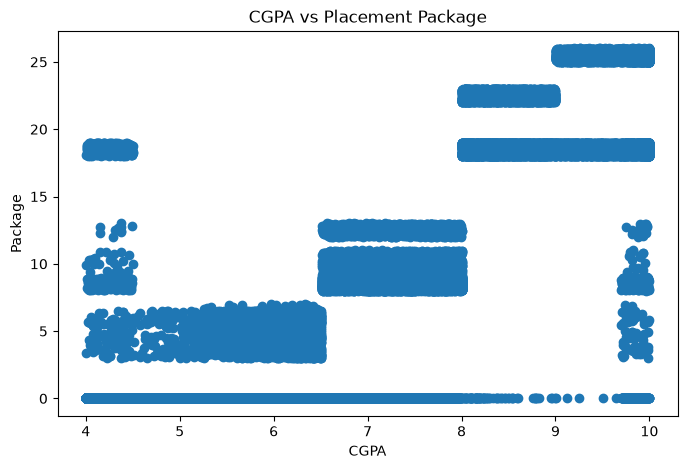

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("CGPA vs Placement Package")

plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data: ", X_train)
print("Testing data: ", X_test)

Training data:         CGPA
39087  9.10
30893  8.23
45278  4.44
16398  6.59
13653  7.46
...     ...
11284  5.35
44732  6.99
38158  5.89
860    8.28
15795  9.74

[40000 rows x 1 columns]
Testing data:         CGPA
33553  8.79
9427   4.78
199    6.81
12447  5.91
39489  5.89
...     ...
28567  6.72
25079  6.65
18707  6.75
15200  8.08
5857   6.86

[10000 rows x 1 columns]


In [18]:
model = LinearRegression()

In [20]:
model.fit(X_train, y_train)

print("Slope (β1): ", model.coef_[0])
print("Intercept (β0): ", model.intercept_)

Slope (β1):  [4.49735128]
Intercept (β0):  [-23.04881068]


In [21]:
y_pred = model.predict(X_test)

print("Actual values: ", y_test.values)
print("Predicted values: ", y_pred)

Actual values:  [[18.48]
 [ 0.  ]
 [ 0.  ]
 ...
 [ 0.  ]
 [22.42]
 [ 8.78]]
Predicted values:  [[16.48290707]
 [-1.55147157]
 [ 7.57815153]
 ...
 [ 7.30831045]
 [13.28978766]
 [ 7.8030191 ]]


In [22]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)
print("R² Percentage:", r2 * 100, "%")

R² Score: 0.669873404447614
R² Percentage: 66.9873404447614 %


In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

Mean Absolute Error: 3.7632724352826075
Mean Squared Error: 25.783718684409898


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Salary Package
Feature names seen at fit time, yet now missing:
- CGPA


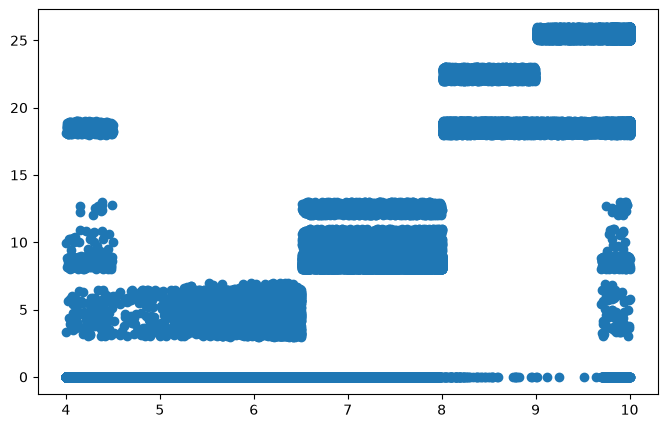

In [24]:
plt.figure(figsize = (8, 5))

plt.scatter(X, y, label = "Actual Data")
plt.plot(X, model.predict(y), label = "Regression Line")

plt.xlabel("CGPA")
plt.ylabel("Placement Package (LPA)")
plt.title("Simple Linear Regression: CGPS vs Placement Package")

plt.legend()
plt.show()

In [25]:
new_cgpa = [[8.5]]
predicted_package = model.predict(new_cgpa)

print("CGPA: ", new_cgpa[0][0])
print("Predicted Placement Package: ", predicted_package[0], "LPA")

CGPA:  8.5
Predicted Placement Package:  [15.17867519] LPA


c:\Users\DELL\OneDrive\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
# Predict for multiple students
new_students = [[7.0], [8.0], [8.5], [9.0], [9.5]]

predicted_packages = model.predict(new_students)

for cgpa, package in zip(new_students, predicted_packages):
    print(f"CGPA: {cgpa[0]} -> Predicted Package: {package.item():.2f} LPA")

CGPA: 7.0 -> Predicted Package: 8.43 LPA
CGPA: 8.0 -> Predicted Package: 12.93 LPA
CGPA: 8.5 -> Predicted Package: 15.18 LPA
CGPA: 9.0 -> Predicted Package: 17.43 LPA
CGPA: 9.5 -> Predicted Package: 19.68 LPA


c:\Users\DELL\OneDrive\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
